In [2]:
%pip install seaborn matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd

In [4]:
# Load the dataset
vendas_df = pd.read_csv('data/vendas.csv')

## Exibindo informações básicas

In [6]:
vendas_df.head()

,data,produto,categoria,quantidade,preco_unitario,cliente,regiao
0,2025-12-09,Headset G,Periféricos,1,2759,Fernanda,Sudeste
1,2025-03-12,Armário P,Móveis,2,4516,Rafael,Norte
2,2025-11-24,Mesa Escritório N,Móveis,1,4347,Rafael,Sudeste
3,2025-09-14,Tênis T,Vestuário,3,3046,Ana,Norte
4,2025-08-03,Boné V,Vestuário,2,4453,Bruno,Centro-Oeste


In [8]:
vendas_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   data            100 non-null    str  
 1   produto         100 non-null    str  
 2   categoria       100 non-null    str  
 3   quantidade      100 non-null    int64
 4   preco_unitario  100 non-null    int64
 5   cliente         100 non-null    str  
 6   regiao          100 non-null    str  
dtypes: int64(2), str(5)
memory usage: 5.6 KB


In [10]:
vendas_df["receita_total"] = vendas_df["preco_unitario"] * vendas_df["quantidade"]
vendas_df.head()

,data,produto,categoria,quantidade,preco_unitario,cliente,regiao,receita_total
0,2025-12-09,Headset G,Periféricos,1,2759,Fernanda,Sudeste,2759
1,2025-03-12,Armário P,Móveis,2,4516,Rafael,Norte,9032
2,2025-11-24,Mesa Escritório N,Móveis,1,4347,Rafael,Sudeste,4347
3,2025-09-14,Tênis T,Vestuário,3,3046,Ana,Norte,9138
4,2025-08-03,Boné V,Vestuário,2,4453,Bruno,Centro-Oeste,8906


In [41]:
vendas_df["mes"] = pd.to_datetime(vendas_df["data"]).dt.month

## Fazendo consultas específicas

In [29]:
# Listando os produtos mais vendidos na categoria "Eletrônicos" agrupados por região ordenados por quantidade
(vendas_df[vendas_df["categoria"] == "Eletrônicos"]
 .groupby("regiao")
 .sum()
 .sort_values(
    by="quantidade",
    ascending=False)
 .head())

,data,produto,categoria,quantidade,preco_unitario,cliente,receita_total,mes
regiao,,,,,,,,
Sudeste,2025-07-242025-01-302025-08-062025-07-052025-0...,Tablet DNotebook XFone CFone CMonitor BMonitor B,EletrônicosEletrônicosEletrônicosEletrônicosEl...,23,15371,FernandaLucasRafaelFernandaPedroCarla,51158,39
Sul,2025-05-202025-11-242025-07-072025-08-012025-0...,Monitor BNotebook XTablet DFone CMonitor BTabl...,EletrônicosEletrônicosEletrônicosEletrônicosEl...,22,25936,LucasAnaCamilaPedroLucasJoãoLucasRafaelCarla,58679,62
Nordeste,2025-04-222025-05-302025-11-202025-01-042025-0...,Celular ATablet DNotebook XNotebook XCelular A,EletrônicosEletrônicosEletrônicosEletrônicosEl...,16,13593,FernandaMariaPedroPedroCarla,51890,24
Norte,2025-09-192025-04-092025-10-052025-11-29,Notebook XCelular ACelular AFone C,EletrônicosEletrônicosEletrônicosEletrônicos,12,12680,RafaelPedroPedroLucas,38116,34
Centro-Oeste,2025-06-012025-04-012025-11-132025-03-18,Celular AFone CFone CNotebook X,EletrônicosEletrônicosEletrônicosEletrônicos,11,14408,JoãoLucasRafaelAna,39546,24


## Gerando visualizações

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

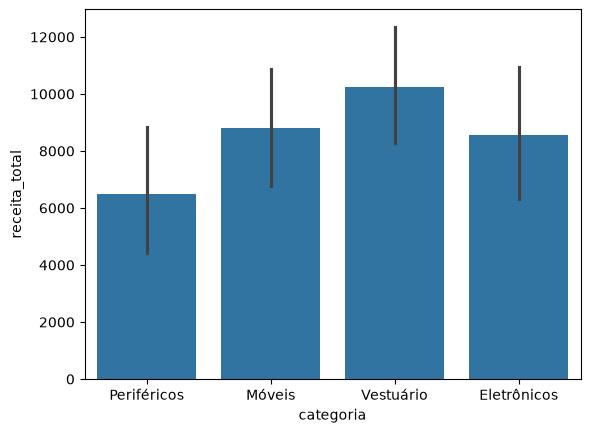

In [26]:
sns.barplot(data=vendas_df, y="receita_total", x="categoria")
plt.show()

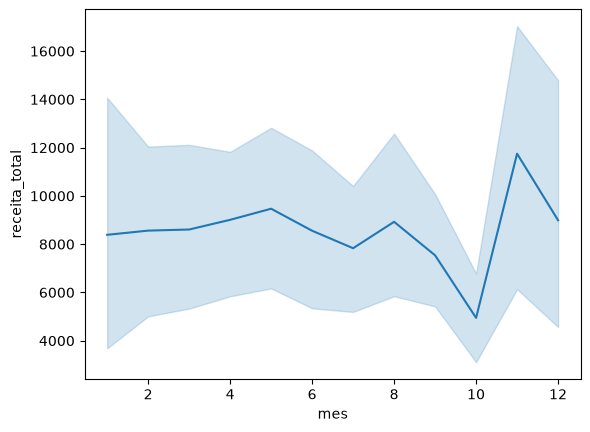

<Figure size 1000x600 with 0 Axes>

In [45]:
sns.lineplot(data=vendas_df, y="receita_total", x="mes")
plt.figure(figsize=(10, 6))
plt.show()